c:\Users\ADMIN\anaconda3\envs\project\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm



Rows: 7064 | Major categories: 20
Train size: 5651 Holdout size: 1413
Loading SBERT: all-MiniLM-L6-v2


Batches: 100%|██████████| 221/221 [00:45<00:00,  4.82it/s]



Training CV (NO LEAK)...

=== FOLD 1 ===
Fold 1 AUC: 0.9592394533571005

=== FOLD 2 ===
Fold 2 AUC: 0.9630059523809524

=== FOLD 3 ===
Fold 3 AUC: 0.9628226817042606

=== FOLD 4 ===
Fold 4 AUC: 0.9662233709273182

=== FOLD 5 ===
Fold 5 AUC: 0.9647472345704539

=== OVERALL OOF AUC: 0.9629916353685092 ===


TRAINING FINAL MODEL ON FULL TRAIN SET (ARTIFACTS)
Final model trained on TRAIN set. Artifacts ready: nn_final, ohe_final, scaler_final, clf_final.

Part 2: inference helpers and Trust Score (Balanced) ready.

BUILDING HOLDOUT FEATURES

EVALUATING ON HOLDOUT TEST SET (20%) - 2 SCENARIOS

=== SCENARIO 1: Sản phẩm mới (KHÔNG có comment/rating) ===

HOLDOUT TEST AUC (sản phẩm mới): 0.6756

=== SCENARIO 2: Sản phẩm đã có comment/rating ===

HOLDOUT TEST AUC (sản phẩm có dữ liệu): 0.9648

DEMO: SO SÁNH 3 CHIẾN LƯỢC TỐI ƯU GIÁ

📋 THÔNG TIN SẢN PHẨM:
   Tên: Bộ váy hai mảnh CHANGTONG cổ chữ V cotton thoáng khí phong cách Hàn Quốc thanh l...
   Cửa hàng: Changtong Fashion
   Phân loại: Thời 

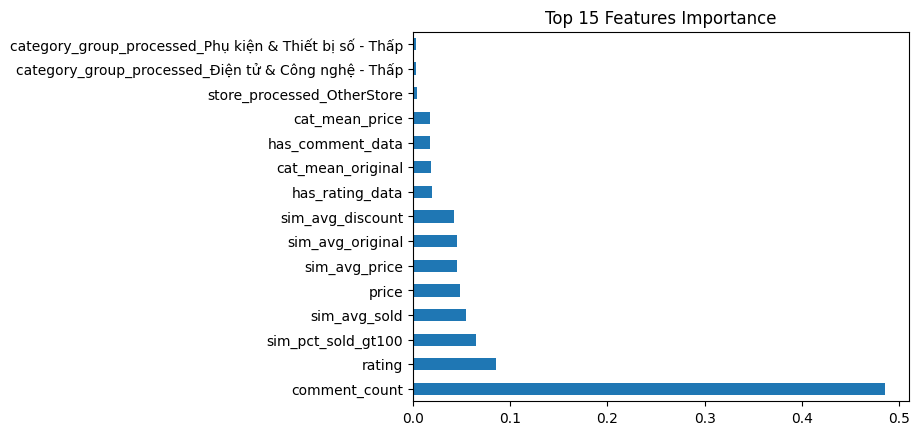

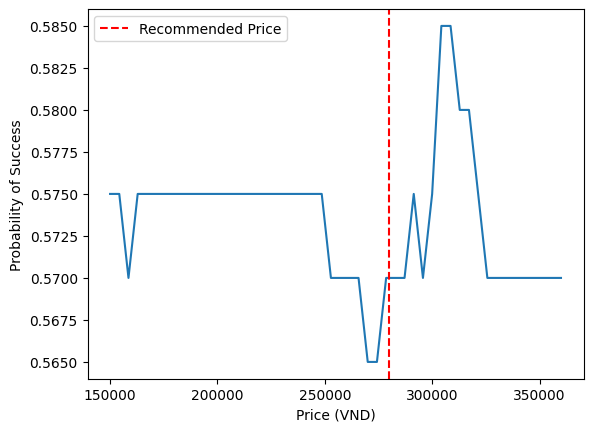

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from Price_opt_production_original import (
    recommend_price, 
    clf_final, 
    X_final, 
    prepare_input_features,
    predict_prob_sold_gt100
)

# Trực quan hóa Feature Importance
feat_importances = pd.Series(clf_final.feature_importances_, index=X_final.columns)
feat_importances.nlargest(15).plot(kind='barh', title='Top 15 Features Importance')
plt.show()

# Tạo dữ liệu cho đường cong tối ưu
original_price = 300000
test_prices = np.linspace(original_price * 0.5, original_price * 1.2, 50)
probs = []

for p in test_prices:
    fv = prepare_input_features("Tên SP", "Tên Store", "Category", p)
    probs.append(predict_prob_sold_gt100(fv))

# Vẽ biểu đồ tối ưu hóa (Xác suất vs Giá)
plt.plot(test_prices, probs)
plt.axvline(x=280000, color='r', linestyle='--', label='Recommended Price')
plt.xlabel('Price (VND)')
plt.ylabel('Probability of Success')
plt.legend()
plt.show()